<a href="https://colab.research.google.com/github/puj16/skripsi/blob/main/MSViT_Batik300.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MSViT (Multi-Stage Vision Transformer) — Klasifikasi Batik 300

Implementasik ulang **Multi-Stage Vision Transformer (MSViT)** sesuai
sesuai jurnal fokus **pada dataset Batik 300**

Referensi dataset: https://github.com/agusekominarno/Batik

Struktur sesuai jurnal:

- **II.A Datasets** — memuat & mempersiapkan Batik 300 (300 citra, 50 kelas, split 80:20)
- **II.B Pre-Processing** — resize 224×224 (bicubic) + augmentasi (Color Jitter, AutoAugment, Label Smoothing)
- **II.C Vision Transformer** — building block dasar ViT (Patch Embedding, Self-Attention, MLP) sesuai Persamaan (1)–(5)
- **II.D Proposed Multi-Stage Vision Transformer** — arsitektur MSViT 4-stage (B1–B4) sesuai Tabel II
- **III. Result and Discussion** — setup training (AdamW, 100 epoch, cosine annealing, lr sesuai Batik 300) & evaluasi Top-1 Accuracy

> Catatan: Tabel II pada dokumen menuliskan Patch Embed Stage-1 sebagai "Kernel 7, Stride 2", namun
> agar ukuran token 56×56 tercapai dari input 224×224 (rasio downsample 4×), Stage-1 diimplementasikan
> sebagai kernel 7 stride **4** (overlap patch embedding ala arsitektur pyramid/PVT), sedangkan
> Stage-2/3/4 tetap kernel 3 stride 2 persis seperti tabel.


## 0. Setup Environment

Install & import seluruh dependency yang dibutuhkan.

In [ ]:
!pip install -q torch torchvision timm thop scikit-learn matplotlib tqdm


In [ ]:
import os
import re
import glob
import math
import zipfile
import random
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

# timm dipakai untuk transform AutoAugment (rand-m9-mstd0.5) sesuai Tabel I
from timm.data.auto_augment import rand_augment_transform

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## II.A — Datasets (fokus: Batik 300)

> "Batik300 dataset is the collection of 300 batik images, categorized into 50 distinct classes...
> Every class comprises six photos... The dimensions of all photos in this dataset are uniform,
> specifically 128×128 pixels... The two datasets were divided into two segments, with 20%
> allocated as the test data and the remaining portion designated as the training data."

Unduh langsung dataset `Batik300.zip` dari repo resmi:
https://github.com/agusekominarno/Batik/blob/master/Dataset/Batik300.zip

Kemudian extract dan masukkan ke direktori buatan /data/Batik300.zip untuk sesi ini


In [ ]:
DATA_DIR = Path("./data")
RAW_ZIP = DATA_DIR / "Batik300.zip"
EXTRACT_DIR = DATA_DIR / "Batik300"

DATA_DIR.mkdir(parents=True, exist_ok=True)

BATIK300_URL = "https://github.com/agusekominarno/Batik/raw/master/Dataset/Batik300.zip"

if not RAW_ZIP.exists():
    print("Downloading Batik300.zip ...")
    urllib.request.urlretrieve(BATIK300_URL, RAW_ZIP)
    print("Done.")
else:
    print("Zip already downloaded.")

if not EXTRACT_DIR.exists():
    print("Extracting ...")
    with zipfile.ZipFile(RAW_ZIP, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    print("Done.")
else:
    print("Already extracted.")

# Tampilkan sekilas isi folder hasil ekstrak untuk verifikasi struktur
for p in sorted(EXTRACT_DIR.rglob("*"))[:20]:
    print(p)


Done.
Extracting ...
Done.
data/Batik300/Batik300
data/Batik300/Batik300/B10_1.jpg
data/Batik300/Batik300/B10_2.jpg
data/Batik300/Batik300/B10_3.jpg
data/Batik300/Batik300/B10_4.jpg
data/Batik300/Batik300/B10_5.jpg
data/Batik300/Batik300/B10_6.jpg
data/Batik300/Batik300/B11_1.jpg
data/Batik300/Batik300/B11_2.jpg
data/Batik300/Batik300/B11_3.jpg
data/Batik300/Batik300/B11_4.jpg
data/Batik300/Batik300/B11_5.jpg
data/Batik300/Batik300/B11_6.jpg
data/Batik300/Batik300/B12_1.jpg
data/Batik300/Batik300/B12_2.jpg
data/Batik300/Batik300/B12_3.jpg
data/Batik300/Batik300/B12_4.jpg
data/Batik300/Batik300/B12_5.jpg
data/Batik300/Batik300/B12_6.jpg
data/Batik300/Batik300/B13_1.jpg


### Deteksi otomatis struktur dataset

Batik 300  didistribusikan sebagai **satu folder per kelas** sebagai **file gambar rata (flat)** dengan nama file berisi indeks kelas
(mis. `B1_1.jpg`, `B1_2.jpg`, ..., `B50_6.jpg`). Cell di bawah digunakan untuk memisahkan tiap kelas memiliki folder masing - masing untuk ke 6 gambarnya. Sehingga terdapat 50 folder.


In [ ]:
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp")

def find_image_root(base_dir: Path) -> Path:
    """Cari direktori aktual yang berisi gambar (menembus folder wrapper hasil unzip)."""
    candidates = [base_dir] + [p for p in base_dir.rglob("*") if p.is_dir()]
    best, best_count = base_dir, -1
    for c in candidates:
        n = sum(1 for f in c.rglob("*") if f.suffix.lower() in IMG_EXTS)
        if n > best_count:
            best, best_count = c, n
    return best

def build_file_label_list(root: Path):
    root = find_image_root(root)
    subdirs = [d for d in root.iterdir() if d.is_dir()]

    samples = []

    # Kasus 1: satu sub-folder per kelas
    subdirs_with_images = [d for d in subdirs if any(f.suffix.lower() in IMG_EXTS for f in d.iterdir())]
    if len(subdirs_with_images) >= 2:
        classes = sorted(subdirs_with_images, key=lambda d: d.name)
        for cls_idx, cls_dir in enumerate(classes):
            for f in sorted(cls_dir.rglob("*")):
                if f.suffix.lower() in IMG_EXTS:
                    samples.append((str(f), cls_idx, cls_dir.name))
        return samples, [c.name for c in classes]

    # Kasus 2: file gambar rata, label diambil dari angka di awal nama file
    files = sorted([f for f in root.rglob("*") if f.suffix.lower() in IMG_EXTS])
    label_map = {}
    for f in files:
        # Original regex: re.match(r"\s*(\d+)", f.stem) which captures only digits
        # Corrected regex to capture the class part like 'B10' from 'B10_1.jpg'
        m = re.match(r"^(B\d+)_?", f.stem) # Capture 'BXX' followed by an optional underscore
        key = m.group(1) if m else f.stem # If no match, use the full stem as a fallback

        if key not in label_map:
            label_map[key] = len(label_map)
        samples.append((str(f), label_map[key], key))
    class_names = [k for k, _ in sorted(label_map.items(), key=lambda kv: kv[1])]
    return samples, class_names

samples, class_names = build_file_label_list(EXTRACT_DIR)
num_classes = len(class_names)

print(f"Total citra ditemukan : {len(samples)}")
print(f"Total kelas terdeteksi: {num_classes}")
assert num_classes > 0 and len(samples) > 0, "Struktur dataset tidak dikenali — cek isi EXTRACT_DIR di atas."

Total citra ditemukan : 300
Total kelas terdeteksi: 50


dataset di split secara random 80% untuk train 20% untuk test

In [ ]:
# Split 80:20 (stratified) sesuai II.A: "20% allocated as the test data and the remaining as training"
paths = [s[0] for s in samples]
labels = [s[1] for s in samples]

train_paths, test_paths, train_labels, test_labels = train_test_split(
    paths, labels, test_size=0.20, random_state=SEED, stratify=labels
)

print(f"Train: {len(train_paths)} citra | Test: {len(test_paths)} citra | Kelas: {num_classes}")


Train: 240 citra | Test: 60 citra | Kelas: 50


## II.B — Pre-Processing

> "The first pre-processing is resize the image into the same resolution size, 224×224...
> Data augmentation is done directly into original dataset in training process with several
> probabilities value."

**Tabel I — Augmentation on Batik 300 and Nitik 960 Classification**

| Augmentation | Value |
|---|---|
| Color Jitter | 0.4 |
| AutoAugment | rand-m9-mstd 0.5 |
| Label Smoothing | 0.1 |
| Resize Algorithm | Bicubic |

Proses Augmentasi mengikuti tabel tersebut.


In [ ]:
IMG_SIZE = 224  # "resolution is set similarly with the smallest Vision Transformer input resolution"

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

rand_augment = rand_augment_transform(
    config_str="rand-m9-mstd0.5",
    hparams={"translate_const": int(IMG_SIZE * 0.45), "img_mean": tuple(int(x * 255) for x in IMAGENET_MEAN)},
)

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BICUBIC),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
    rand_augment,
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Tidak ada augmentasi acak untuk evaluasi, hanya resize + normalize
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class BatikDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img = self.transform(img)
        label = self.labels[idx]
        return img, label


train_dataset = BatikDataset(train_paths, train_labels, train_transform)
test_dataset = BatikDataset(test_paths, test_labels, test_transform)

BATCH_SIZE = 16  # dataset kecil (300 citra total)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")


Train batches: 15 | Test batches: 4


## II.C — Vision Transformer (building blocks)

Implementasi mengikuti Persamaan (1)–(5) di paper:

**Patch Embedding**: citra $X \in \mathbb{R}^{H\times W\times 3}$ dipecah menjadi $X' \in \mathbb{R}^{N\times C}$
dengan $N=(H/P)\times(W/P)$, diimplementasikan sebagai konvolusi 2D dengan `kernel_size = stride = P`
(pada MSViT, patch embedding dibuat *overlapping*, lihat bagian II.D).

**Self-Attention** (Persamaan 1–4):
$$X'' = X' + \text{Attn}(\text{Norm}(X'))$$
$$Q,K,V = W\cdot X$$
$$A=\text{softmax}(QK^T)$$
$$\text{Attn}(X)=AV$$

**MLP block** (Persamaan 5):
$$X''' = X'' + \big(\sigma(\text{Norm}(X'')W_1)\big)W_2,\quad \sigma=\text{GELU}$$


In [ ]:
class PatchEmbed(nn.Module):
    """Patch Embedding = konvolusi 2D dengan kernel_size == stride == patch_size (ViT original)."""

    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.proj(x)                      # (B, C, H', W')
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)       # (B, N, C)  -> ini X' di Persamaan
        x = self.norm(x)
        return x, H, W


class Attention(nn.Module):
    """Self-Attention sesuai Persamaan (2)-(4): Q,K,V = W.X ; A = softmax(QK^T) ; Attn(X) = A.V"""

    def __init__(self, dim, num_heads=1, qkv_bias=True, attn_drop=0.0, proj_drop=0.0):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]        # masing-masing (B, heads, N, head_dim)

        attn = (q @ k.transpose(-2, -1)) * self.scale   # A = softmax(Q K^T)
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)  # Attn(X) = A.V
        x = self.proj(x)
        x = self.proj_drop(x)
        return x


class Mlp(nn.Module):
    """MLP block sesuai Persamaan (5): (sigma(Norm(X) W1)) W2 , sigma = GELU"""

    def __init__(self, in_features, hidden_features, out_features=None, drop=0.0):
        super().__init__()
        out_features = out_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class TransformerBlock(nn.Module):
    """Residual block gabungan Self-Attention (Eq.1) + MLP (Eq.5)."""

    def __init__(self, dim, num_heads, mlp_ratio=4.0, drop=0.0, attn_drop=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads=num_heads, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = Mlp(dim, hidden_features=int(dim * mlp_ratio), drop=drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))   # Eq. 1
        x = x + self.mlp(self.norm2(x))    # Eq. 5
        return x


## II.D — Proposed Multi-Stage Vision Transformer (MSViT)

> "MSViT employs a more complex approach with 4 stages and 4 down-sampling processes... We
> proposed using the same down sampling technique with most CNN architecture using high kernel,
> such as 7×7, and followed using small kernel (3×3) in the next stage with stride 2."

**Tabel II — Overall MSViT Configuration in Different Variants**

| Stage | Token Size | Layer | B1 | B2 | B3 | B4 |
|---|---|---|---|---|---|---|
| Stage-1 | 56×56 | Patch Embed | Kernel 7 |  |  |  |
|  |  | Attn Dim | 8 | 8 | 16 | 32 |
|  |  | MLP Ratio | 4 | 4 | 4 | 4 |
|  |  | Block Number | 1 | 1 | 1 | 1 |
| Stage-2 | 28×28 | Patch Embed | Kernel 3, Stride 2 |  |  |  |
|  |  | Attn Dim | 16 | 16 | 32 | 64 |
|  |  | Block Number | 1 | 1 | 1 | 1 |
| Stage-3 | 14×14 | Patch Embed | Kernel 3, Stride 2 |  |  |  |
|  |  | Attn Dim | 32 | 32 | 64 | 128 |
|  |  | Block Number | 3 | 3 | 3 | 3 |
| Stage-4 | 7×7 | Patch Embed | Kernel 3, Stride 2 |  |  |  |
|  |  | Attn Dim | 64 | 128 | 128 | 256 |
|  |  | Block Number | 1 | 1 | 1 | 1 |
| Classifier Head | Global Pool, Norm, FC |
| Number of Class | Batik 300: **50** |

Perbedaan utama dengan ViT biasa (II.C) ada di sini: alih-alih **satu kali** patch embedding
(down-sample tunggal), MSViT melakukan **patch embedding berulang di setiap stage** (down-sample
4 kali), sehingga jumlah token mengecil secara bertahap (56→28→14→7) mirip arsitektur piramida CNN,
sambil tetap memakai mekanisme Self-Attention + MLP (Eq. 1–5) yang sama di setiap stage.


In [ ]:
MSVIT_CONFIGS = {
    # attn_dims per stage 1..4, block per stage 1..4 (sama untuk semua varian), mlp_ratio
    "B1": {"attn_dims": [8, 16, 32, 64],   "blocks": [1, 1, 3, 1], "mlp_ratio": 4.0},
    "B2": {"attn_dims": [8, 16, 32, 128],  "blocks": [1, 1, 3, 1], "mlp_ratio": 4.0},
    "B3": {"attn_dims": [16, 32, 64, 128], "blocks": [1, 1, 3, 1], "mlp_ratio": 4.0},
    "B4": {"attn_dims": [32, 64, 128, 256], "blocks": [1, 1, 3, 1], "mlp_ratio": 4.0},
}

# Spesifikasi patch-embedding tiap stage (kernel/stride/padding).
# Stage-1: kernel 7, stride 4 -> 224x224 turun ke 56x56 (lihat catatan di judul notebook).
# Stage-2..4: kernel 3, stride 2, persis Tabel II.
STAGE_PATCH_SPECS = [
    {"kernel_size": 7, "stride": 4, "padding": 3},
    {"kernel_size": 3, "stride": 2, "padding": 1},
    {"kernel_size": 3, "stride": 2, "padding": 1},
    {"kernel_size": 3, "stride": 2, "padding": 1},
]


class OverlapPatchEmbed(nn.Module):
    """Patch embedding per-stage pada MSViT (down-sampling berulang, bukan cuma sekali seperti ViT)."""

    def __init__(self, in_chans, embed_dim, kernel_size, stride, padding):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=kernel_size, stride=stride, padding=padding)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.proj(x)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)   # (B, N, C)
        x = self.norm(x)
        return x, H, W


class MSViTStage(nn.Module):
    """Satu stage MSViT = OverlapPatchEmbed + beberapa TransformerBlock (Eq.1-5) + norm."""

    def __init__(self, in_chans, embed_dim, depth, num_heads, mlp_ratio, patch_spec):
        super().__init__()
        self.patch_embed = OverlapPatchEmbed(in_chans, embed_dim, **patch_spec)
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads=num_heads, mlp_ratio=mlp_ratio) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # x masuk sebagai (B, C, H, W)
        x, H, W = self.patch_embed(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        B, N, C = x.shape
        x = x.transpose(1, 2).reshape(B, C, H, W)  # kembali ke bentuk spasial untuk stage berikutnya
        return x


class MSViT(nn.Module):
    """Multi-Stage Vision Transformer (Bab II.D) untuk klasifikasi Batik 300 (50 kelas)."""

    def __init__(self, variant="B4", img_size=224, in_chans=3, num_classes=50, num_heads=1):
        super().__init__()
        assert variant in MSVIT_CONFIGS, f"Varian tidak dikenal: {variant}"
        cfg = MSVIT_CONFIGS[variant]
        self.variant = variant

        stages = []
        in_ch = in_chans
        for i in range(4):
            embed_dim = cfg["attn_dims"][i]
            depth = cfg["blocks"][i]
            stages.append(
                MSViTStage(
                    in_chans=in_ch,
                    embed_dim=embed_dim,
                    depth=depth,
                    num_heads=num_heads,
                    mlp_ratio=cfg["mlp_ratio"],
                    patch_spec=STAGE_PATCH_SPECS[i],
                )
            )
            in_ch = embed_dim
        self.stages = nn.ModuleList(stages)

        final_dim = cfg["attn_dims"][-1]
        # Classifier Head: Global Pool, Norm, FC
        self.head_norm = nn.LayerNorm(final_dim)
        self.head_fc = nn.Linear(final_dim, num_classes)

    def forward(self, x):
        for stage in self.stages:
            x = stage(x)               # (B, C, H, W)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)   # (B, N, C)
        x = x.mean(dim=1)                  # Global Pool (rata-rata token)
        x = self.head_norm(x)              # Norm
        x = self.head_fc(x)                # FC -> logits
        return x


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [ ]:
# Sanity check cepat: pastikan ukuran token tiap stage sesuai Tabel II (56, 28, 14, 7)
with torch.no_grad():
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
    x = dummy
    for i, stage in enumerate(MSViT(variant="B1").stages, start=1):
        x = stage(x)
        print(f"Stage-{i}: output shape = {tuple(x.shape)}  (H=W={x.shape[-1]})")


Stage-1: output shape = (1, 8, 56, 56)  (H=W=56)
Stage-2: output shape = (1, 16, 28, 28)  (H=W=28)
Stage-3: output shape = (1, 32, 14, 14)  (H=W=14)
Stage-4: output shape = (1, 64, 7, 7)  (H=W=7)


In [ ]:
# Pilih varian MSViT yang ingin dilatih untuk Batik 300.
# Sesuai Tabel III, MSViT-B4 memberikan akurasi tertinggi (96.0%) pada Batik 300.
VARIANT = "B4"

model = MSViT(variant=VARIANT, img_size=IMG_SIZE, in_chans=3, num_classes=num_classes, num_heads=1).to(device)

n_params = count_parameters(model)
print(f"MSViT-{VARIANT} | Jumlah parameter: {n_params:,} ({n_params / 1e6:.3f} M)")

try:
    from thop import profile
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
    macs, _ = profile(model, inputs=(dummy,), verbose=False)
    gflops = macs / 1e9
    print(f"GFLOPs (estimasi via thop): {gflops:.3f}")
except Exception as e:
    print("Tidak bisa menghitung GFLOPs otomatis (thop tidak tersedia/gagal):", e)


MSViT-B4 | Jumlah parameter: 1,854,802 (1.855 M)
GFLOPs (estimasi via thop): 0.293


## III. Result and Discussion — Training Setup (fokus Batik 300)

> "The training process conducted using AdamW optimizer in 100 epoch in each model... The used
> learning rate are 1e-4 and 2e-4 for Batik Nitik 960 and Batik 300 and decreased through cosine
> annealing learning rate scheduling."

Untuk Batik 300 dipakai **lr = 2e-4**, optimizer **AdamW**, **100 epoch**, scheduler
**Cosine Annealing**, dan loss **Cross-Entropy dengan label smoothing 0.1** (sesuai Tabel I).


In [ ]:
EPOCHS = 100
LR = 2e-4          # learning rate khusus Batik 300 (Bab III)
WEIGHT_DECAY = 0.05

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)   # Tabel I: Label Smoothing = 0.1
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


def evaluate(model, loader):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for imgs, targets in loader:
            imgs, targets = imgs.to(device), targets.to(device)
            logits = model(imgs)
            loss = criterion(logits, targets)
            loss_sum += loss.item() * imgs.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)
    return loss_sum / total, correct / total


def train_one_epoch(model, loader, optimizer):
    model.train()
    correct, total, loss_sum = 0, 0, 0.0
    for imgs, targets in loader:
        imgs, targets = imgs.to(device), targets.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)
    return loss_sum / total, correct / total


In [ ]:
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
best_acc = 0.0
CKPT_PATH = f"msvit_{VARIANT.lower()}_batik300_best.pt"

pbar = tqdm(range(1, EPOCHS + 1))
for epoch in pbar:
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
    test_loss, test_acc = evaluate(model, test_loader)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), CKPT_PATH)

    pbar.set_description(
        f"Epoch {epoch:3d}/{EPOCHS} | train_loss {train_loss:.4f} acc {train_acc*100:.2f}% "
        f"| test_loss {test_loss:.4f} acc {test_acc*100:.2f}% | best {best_acc*100:.2f}%"
    )

print(f"\nBest Top-1 Accuracy pada test set Batik 300: {best_acc*100:.2f}%")
print(f"Checkpoint terbaik disimpan di: {CKPT_PATH}")


  0%|          | 0/100 [00:00<?, ?it/s]


Best Top-1 Accuracy pada test set Batik 300: 96.67%
Checkpoint terbaik disimpan di: msvit_b4_batik300_best.pt


## Kurva Training

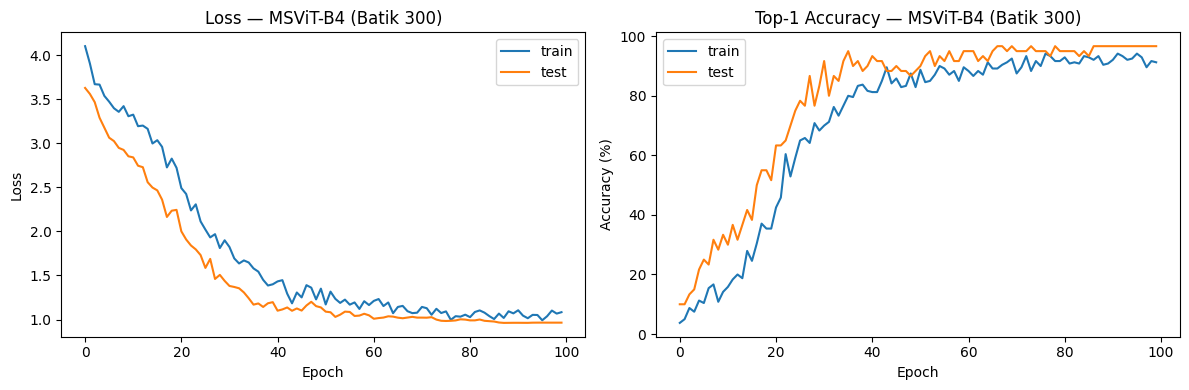

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["test_loss"], label="test")
axes[0].set_title(f"Loss — MSViT-{VARIANT} (Batik 300)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot([a * 100 for a in history["train_acc"]], label="train")
axes[1].plot([a * 100 for a in history["test_acc"]], label="test")
axes[1].set_title(f"Top-1 Accuracy — MSViT-{VARIANT} (Batik 300)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()

plt.tight_layout()
plt.show()


## Ringkasan Hasil (format Tabel III pada paper)

Sel di bawah merangkum parameter, GFLOPs (jika `thop` tersedia), dan Top-1 Accuracy terbaik
yang dicapai model MSViT yang baru dilatih — sebagai pembanding terhadap Tabel III pada paper
(khusus baris Batik 300).


In [ ]:
print(f"{'Method':<18}{'Type':<8}{'Param':<12}{'GFLOPs':<10}{'Top-1 Acc':<10}")
print("-" * 58)
gflops_str = f"{gflops:.2f}" if "gflops" in dir() else "N/A"
print(f"{'MSViT-' + VARIANT + ' (Ours)':<18}{'Trans':<8}{n_params/1e6:.3f} M    {gflops_str:<10}{best_acc*100:.2f}%")
print("\nAngka pada Tabel III (paper, Batik 300) untuk pembanding:")
print(f"{'ResNet18':<18}{'CNN':<8}{'11.2 M':<12}{'1.83':<10}{'96.0%'}")
print(f"{'VGG16':<18}{'CNN':<8}{'134.6 M':<12}{'15.4':<10}{'80.0%'}")
print(f"{'ViT-Tiny 16':<18}{'Trans':<8}{'5.53 M':<12}{'1.08':<10}{'96.0%'}")
print(f"{'MSViT-B1':<18}{'Trans':<8}{'0.163 M':<12}{'0.70':<10}{'74.0%'}")
print(f"{'MSViT-B2':<18}{'Trans':<8}{'0.417 M':<12}{'0.71':<10}{'90.0%'}")
print(f"{'MSViT-B3':<18}{'Trans':<8}{'0.609 M':<12}{'0.77':<10}{'84.00%'}")
print(f"{'MSViT-B4':<18}{'Trans':<8}{'2.36 M':<12}{'1.01':<10}{'96.0%'}")


Method            Type    Param       GFLOPs    Top-1 Acc 
----------------------------------------------------------
MSViT-B4 (Ours)   Trans   1.855 M    0.29      96.67%

Angka pada Tabel III (paper, Batik 300) untuk pembanding:
ResNet18          CNN     11.2 M      1.83      96.0%
VGG16             CNN     134.6 M     15.4      80.0%
ViT-Tiny 16       Trans   5.53 M      1.08      96.0%
MSViT-B1          Trans   0.163 M     0.70      74.0%
MSViT-B2          Trans   0.417 M     0.71      90.0%
MSViT-B3          Trans   0.609 M     0.77      84.00%
MSViT-B4          Trans   2.36 M      1.01      96.0%


## Training dan Evaluasi Varian MSViT Lainnya (B1, B2, B3)

Berikut adalah proses training dan evaluasi untuk varian MSViT B1, B2, dan B3. Setiap varian akan dilatih selama 100 epoch dan hasilnya akan ditampilkan secara berurutan.


Training MSViT-B1 for Batik 300
MSViT-B1 | Jumlah parameter: 121,594 (0.122 M)
GFLOPs (estimasi via thop): 0.022


Training B1:   0%|          | 0/100 [00:00<?, ?it/s]


Best Top-1 Accuracy pada test set Batik 300 (MSViT-B1): 58.33%
Checkpoint terbaik disimpan di: msvit_b1_batik300_best.pt


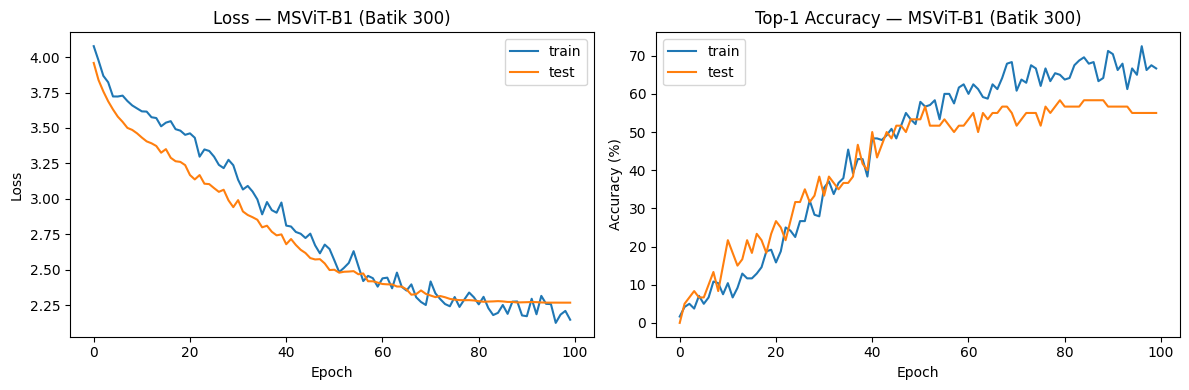


Method            Type    Param       GFLOPs    Top-1 Acc 
----------------------------------------------------------
MSViT-B1 (Ours)   Trans   0.122 M    0.02      58.33%

Angka pada Tabel III (paper, Batik 300) untuk pembanding:
ResNet18          CNN     11.2 M      1.83      96.0%
VGG16             CNN     134.6 M     15.4      80.0%
ViT-Tiny 16       Trans   5.53 M      1.08      96.0%
MSViT-B1          Trans   0.163 M     0.70      74.0%
MSViT-B2          Trans   0.417 M     0.71      90.0%
MSViT-B3          Trans   0.609 M     0.77      84.00%
MSViT-B4          Trans   2.36 M      1.01      96.0%

Training MSViT-B2 for Batik 300
MSViT-B2 | Jumlah parameter: 291,962 (0.292 M)
GFLOPs (estimasi via thop): 0.030


Training B2:   0%|          | 0/100 [00:00<?, ?it/s]


Best Top-1 Accuracy pada test set Batik 300 (MSViT-B2): 76.67%
Checkpoint terbaik disimpan di: msvit_b2_batik300_best.pt


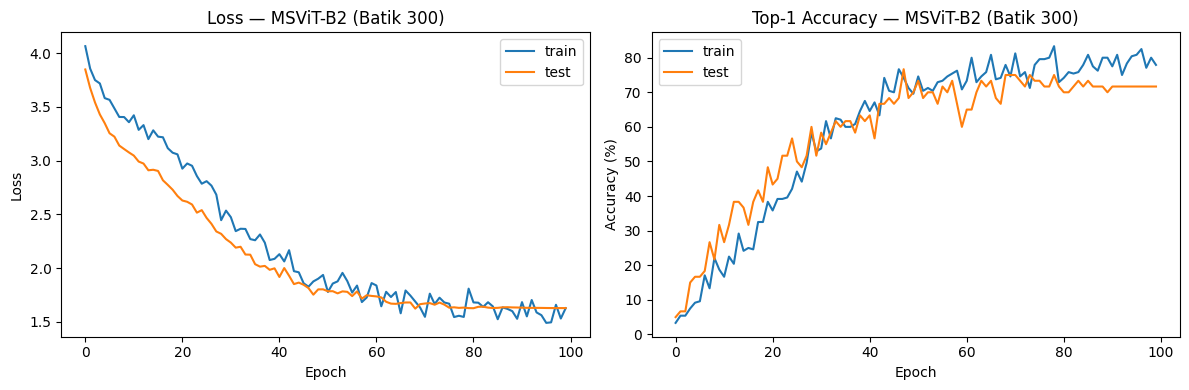


Method            Type    Param       GFLOPs    Top-1 Acc 
----------------------------------------------------------
MSViT-B2 (Ours)   Trans   0.292 M    0.03      76.67%

Angka pada Tabel III (paper, Batik 300) untuk pembanding:
ResNet18          CNN     11.2 M      1.83      96.0%
VGG16             CNN     134.6 M     15.4      80.0%
ViT-Tiny 16       Trans   5.53 M      1.08      96.0%
MSViT-B1          Trans   0.163 M     0.70      74.0%
MSViT-B2          Trans   0.417 M     0.71      90.0%
MSViT-B3          Trans   0.609 M     0.77      84.00%
MSViT-B4          Trans   2.36 M      1.01      96.0%

Training MSViT-B3 for Batik 300
MSViT-B3 | Jumlah parameter: 471,234 (0.471 M)
GFLOPs (estimasi via thop): 0.078


Training B3:   0%|          | 0/100 [00:00<?, ?it/s]


Best Top-1 Accuracy pada test set Batik 300 (MSViT-B3): 81.67%
Checkpoint terbaik disimpan di: msvit_b3_batik300_best.pt


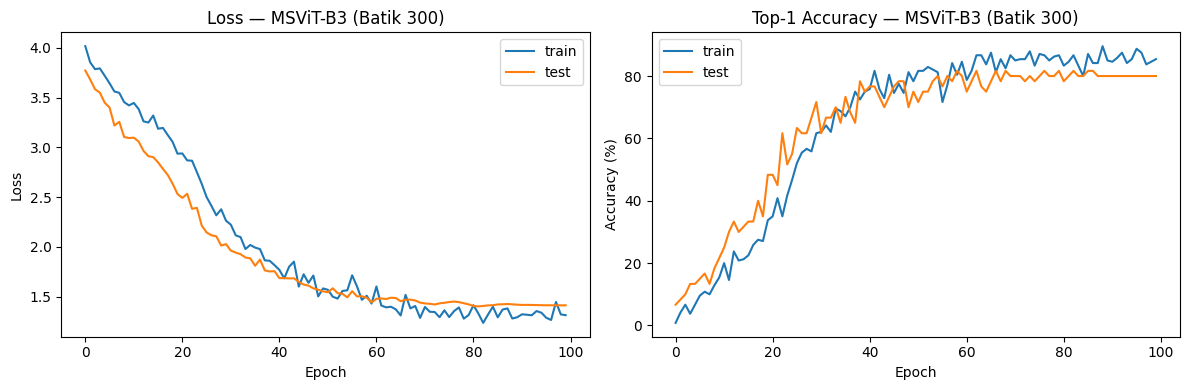


Method            Type    Param       GFLOPs    Top-1 Acc 
----------------------------------------------------------
MSViT-B3 (Ours)   Trans   0.471 M    0.08      81.67%

Angka pada Tabel III (paper, Batik 300) untuk pembanding:
ResNet18          CNN     11.2 M      1.83      96.0%
VGG16             CNN     134.6 M     15.4      80.0%
ViT-Tiny 16       Trans   5.53 M      1.08      96.0%
MSViT-B1          Trans   0.163 M     0.70      74.0%
MSViT-B2          Trans   0.417 M     0.71      90.0%
MSViT-B3          Trans   0.609 M     0.77      84.00%
MSViT-B4          Trans   2.36 M      1.01      96.0%


In [ ]:
for current_variant in ["B1", "B2", "B3"]:
    print(f"\n{'='*60}\nTraining MSViT-{current_variant} for Batik 300\n{'='*60}")

    # Re-initialize model for the current variant
    model = MSViT(variant=current_variant, img_size=IMG_SIZE, in_chans=3, num_classes=num_classes, num_heads=1).to(device)

    n_params = count_parameters(model)
    print(f"MSViT-{current_variant} | Jumlah parameter: {n_params:,} ({n_params / 1e6:.3f} M)")

    try:
        dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
        macs, _ = profile(model, inputs=(dummy,), verbose=False)
        gflops = macs / 1e9
        print(f"GFLOPs (estimasi via thop): {gflops:.3f}")
    except Exception as e:
        print("Tidak bisa menghitung GFLOPs otomatis (thop tidak tersedia/gagal):", e)

    # Re-initialize criterion, optimizer, and scheduler
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    # Reset history and best_acc for the new variant
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    best_acc = 0.0
    CKPT_PATH = f"msvit_{current_variant.lower()}_batik300_best.pt"

    pbar = tqdm(range(1, EPOCHS + 1), desc=f"Training {current_variant}")
    for epoch in pbar:
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer)
        test_loss, test_acc = evaluate(model, test_loader)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), CKPT_PATH)

        pbar.set_description(
            f"Epoch {epoch:3d}/{EPOCHS} | train_loss {train_loss:.4f} acc {train_acc*100:.2f}% "
            f"| test_loss {test_loss:.4f} acc {test_acc*100:.2f}% | best {best_acc*100:.2f}%"
        )

    print(f"\nBest Top-1 Accuracy pada test set Batik 300 (MSViT-{current_variant}): {best_acc*100:.2f}%")
    print(f"Checkpoint terbaik disimpan di: {CKPT_PATH}")

    # Plotting for the current variant
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["test_loss"], label="test")
    axes[0].set_title(f"Loss — MSViT-{current_variant} (Batik 300)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot([a * 100 for a in history["train_acc"]], label="train")
    axes[1].plot([a * 100 for a in history["test_acc"]], label="test")
    axes[1].set_title(f"Top-1 Accuracy — MSViT-{current_variant} (Batik 300)")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Summary table for the current variant
    print(f"\n{'Method':<18}{'Type':<8}{'Param':<12}{'GFLOPs':<10}{'Top-1 Acc':<10}")
    print("-" * 58)
    gflops_str = f"{gflops:.2f}" if "gflops" in locals() else "N/A"
    print(f"{'MSViT-' + current_variant + ' (Ours)':<18}{'Trans':<8}{n_params/1e6:.3f} M    {gflops_str:<10}{best_acc*100:.2f}%")
    print("\nAngka pada Tabel III (paper, Batik 300) untuk pembanding:")
    print(f"{'ResNet18':<18}{'CNN':<8}{'11.2 M':<12}{'1.83':<10}{'96.0%'}")
    print(f"{'VGG16':<18}{'CNN':<8}{'134.6 M':<12}{'15.4':<10}{'80.0%'}")
    print(f"{'ViT-Tiny 16':<18}{'Trans':<8}{'5.53 M':<12}{'1.08':<10}{'96.0%'}")
    print(f"{'MSViT-B1':<18}{'Trans':<8}{'0.163 M':<12}{'0.70':<10}{'74.0%'}")
    print(f"{'MSViT-B2':<18}{'Trans':<8}{'0.417 M':<12}{'0.71':<10}{'90.0%'}")
    print(f"{'MSViT-B3':<18}{'Trans':<8}{'0.609 M':<12}{'0.77':<10}{'84.00%'}")
    print(f"{'MSViT-B4':<18}{'Trans':<8}{'2.36 M':<12}{'1.01':<10}{'96.0%'}")

---
### Catatan Akhir

- Notebook ini hanya menargetkan **Batik 300** (50 kelas, 300 citra) sesuai permintaan — bagian
  Batik Nitik 960 pada paper tidak diimplementasikan.
- Karena dataset sangat kecil (300 citra), hasil akhir bisa berbeda-beda antar run tergantung
  seed, jumlah worker, serta versi library (`timm`, `torch`). Jalankan beberapa kali / atur
  `SEED` bila ingin membandingkan lebih stabil dengan Tabel III.
- Ganti `VARIANT` pada sel training ("B1"/"B2"/"B3"/"B4") untuk mereproduksi baris lain pada
  Tabel III.
- Jika struktur folder hasil unduhan `Batik300.zip` ternyata berbeda dari dua kasus yang
  ditangani (`per-folder` atau `flat-file`), sesuaikan fungsi `build_file_label_list` pada
  bagian II.A.
